# Block Matching using SAD for Motion Estimation

This notebook estimates motion between two images using **block matching** with **SAD (Sum of Absolute Differences)**.

## Approach
- Divide the reference image into fixed-size blocks.
- For each block, search in a local window in the target image.
- Choose the displacement \((u, v)\) with minimum SAD:

$$
\text{SAD}(u,v)=\sum_{i=0}^{B-1}\sum_{j=0}^{B-1}|I_1(x+i,y+j)-I_2(x+u+i,y+v+j)|
$$

- The best \((u,v)\) is the motion vector for that block.

Lower SAD means better match.

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm


def to_gray(image):
    if image is None:
        raise ValueError("Input image is None")
    if image.ndim == 3:
        return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return image.copy()


def sad_cost(block1, block2):
    return np.sum(np.abs(block1.astype(np.int32) - block2.astype(np.int32)))


def find_best_match_sad(img1, img2, x, y, block_size=16, search_radius=8):
    """
    Find best displacement (dx, dy) for the block at top-left (x, y)
    by exhaustive search minimising SAD inside the search window.
    """
    h, w = img1.shape
    block1 = img1[y : y + block_size, x : x + block_size]

    best_sad = float("inf")
    best_dx, best_dy = 0, 0

    for dy in range(-search_radius, search_radius + 1):
        for dx in range(-search_radius, search_radius + 1):
            x2, y2 = x + dx, y + dy
            if x2 < 0 or y2 < 0 or x2 + block_size > w or y2 + block_size > h:
                continue
            current_sad = sad_cost(block1, img2[y2 : y2 + block_size, x2 : x2 + block_size])
            if current_sad < best_sad:
                best_sad = current_sad
                best_dx, best_dy = dx, dy

    return best_dx, best_dy, best_sad


def estimate_motion_field_sad(image1, image2, block_size=16, search_radius=8, stride=None):
    """
    Estimate block-wise motion vectors from image1 → image2 using SAD.

    Returns:
        xs, ys  – block-centre coordinates in image1
        us, vs  – horizontal / vertical displacements  (dx, dy)
        sads    – minimum SAD score per block
    """
    img1 = to_gray(image1)
    img2 = to_gray(image2)

    if img1.shape != img2.shape:
        raise ValueError("Both images must have the same shape")

    h, w = img1.shape
    if stride is None:
        stride = block_size

    xs, ys, us, vs, sads = [], [], [], [], []

    for y in range(0, h - block_size + 1, stride):
        for x in range(0, w - block_size + 1, stride):
            dx, dy, score = find_best_match_sad(
                img1, img2, x, y, block_size=block_size, search_radius=search_radius
            )
            xs.append(x + block_size // 2)
            ys.append(y + block_size // 2)
            us.append(dx)
            vs.append(dy)
            sads.append(score)

    return (
        np.array(xs),
        np.array(ys),
        np.array(us, dtype=np.float32),
        np.array(vs, dtype=np.float32),
        np.array(sads, dtype=np.float32),
    )


def draw_motion_vectors(base_image, xs, ys, us, vs, arrow_scale=3.0, title="Estimated Motion Vectors"):
    """
    Visualise motion vectors overlaid on the reference image.

    arrow_scale – multiply displacement magnitude so small motions are visible.
                  A scale of 3 means a 2-pixel displacement shows as a 6-pixel arrow.
    """
    if base_image.ndim == 2:
        display = cv2.cvtColor(base_image, cv2.COLOR_GRAY2RGB)
    else:
        display = cv2.cvtColor(base_image, cv2.COLOR_BGR2RGB)

    magnitude = np.sqrt(us.astype(np.float64) ** 2 + vs.astype(np.float64) ** 2)

    # Only plot blocks that actually moved
    moving = magnitude > 0.5
    if not np.any(moving):
        print("No significant motion detected – showing all vectors.")
        moving = np.ones(len(xs), dtype=bool)

    xs_m, ys_m = xs[moving], ys[moving]
    us_m, vs_m = us[moving], vs[moving]
    mag_m = magnitude[moving]

    # Normalise magnitude for colour mapping
    norm = plt.Normalize(vmin=0, vmax=max(mag_m.max(), 1))
    colors = cm.plasma(norm(mag_m))

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(display)
    q = ax.quiver(
        xs_m,
        ys_m,
        us_m * arrow_scale,
        vs_m * arrow_scale,
        color=colors,
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.004,
        headwidth=4,
        headlength=5,
    )

    sm = plt.cm.ScalarMappable(cmap="plasma", norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Motion magnitude (px)")
    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

    print(f"Blocks with motion > 0.5 px: {moving.sum()} / {len(xs)}")
    print(f"Max displacement magnitude : {mag_m.max():.2f} px")
    print(f"Mean displacement magnitude: {mag_m.mean():.2f} px")


Using cached file: vtest.avi
Frames           : 10 → 15  (gap = 5 frames)
Image size       : 320 × 240 px
Block / radius   : 16 px  / ±8 px
Textured blocks  : 722 / 1131
Median SAD       : 62.0
Motion max mag   : 11.31 px
Motion mean mag  : 0.74 px
Dominant (dx,dy) : (0.0, 0.0) px


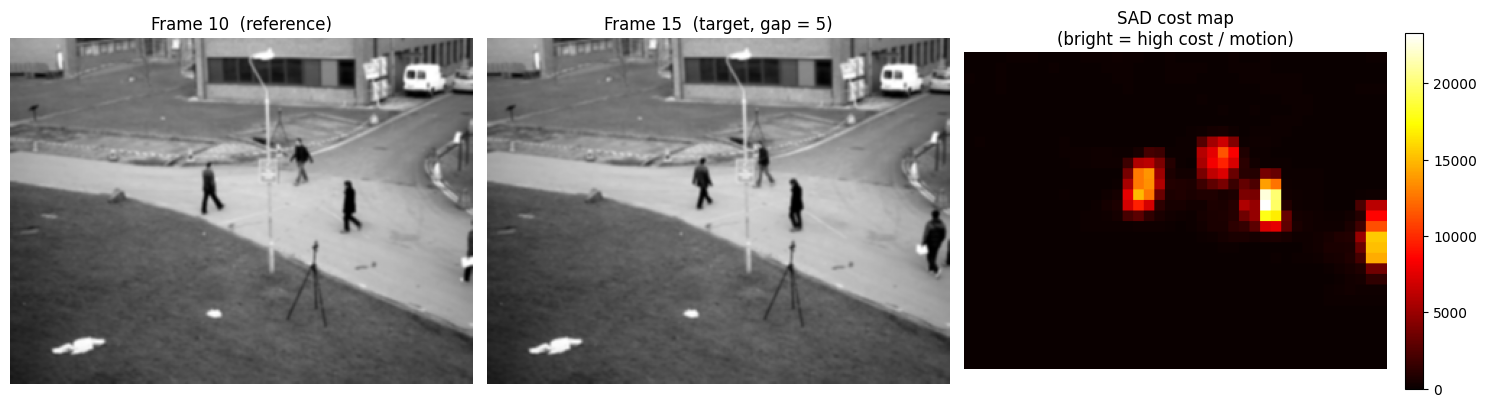

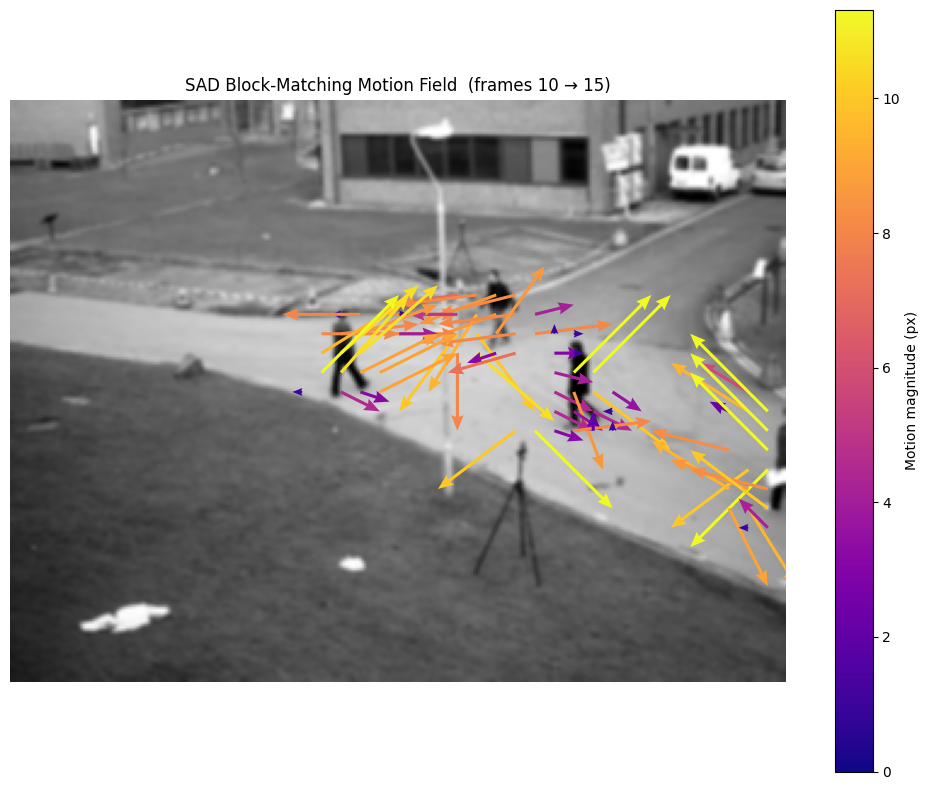

Blocks with motion > 0.5 px: 76 / 722
Max displacement magnitude : 11.31 px
Mean displacement magnitude: 7.01 px


In [9]:
import os
import urllib.request

# ── 1. Download video ────────────────────────────────────────────────────────
VIDEO_URL  = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/vtest.avi"
VIDEO_PATH = "vtest.avi"

if not os.path.exists(VIDEO_PATH):
    print("Downloading vtest.avi …")
    urllib.request.urlretrieve(VIDEO_URL, VIDEO_PATH)
    print("Downloaded:", VIDEO_PATH)
else:
    print("Using cached file:", VIDEO_PATH)

# ── 2. Extract two frames ────────────────────────────────────────────────────
# Gap of 5 frames (~0.2 s at 25 fps).
# Pedestrians move ~3–6 px at 320-px scale — well within the ±8 px search window.
# Larger gaps cause displacement to exceed the search radius → random false matches.
FRAME_A, FRAME_B = 10, 15

def _read_frame(path, idx):
    cap = cv2.VideoCapture(path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, frame = cap.read()
    cap.release()
    return ok, frame

ok1, frame1 = _read_frame(VIDEO_PATH, FRAME_A)
ok2, frame2 = _read_frame(VIDEO_PATH, FRAME_B)

if not ok1 or not ok2:
    raise RuntimeError("Could not read frames from video.")

# ── 3. Pre-process — IDENTICAL transform applied to both frames ──────────────
# IMPORTANT: any per-image operation (e.g. equalizeHist) that changes pixel values
# differently for each frame destroys SAD's inter-frame consistency and causes
# random false matches.  We only apply a mild Gaussian blur (same parameters,
# same effect on both) to reduce sensor noise without altering relative intensities.
gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

TARGET_W = 320
TARGET_H = int(gray1.shape[0] * (TARGET_W / gray1.shape[1]))

real_img1 = cv2.resize(gray1, (TARGET_W, TARGET_H), interpolation=cv2.INTER_AREA)
real_img2 = cv2.resize(gray2, (TARGET_W, TARGET_H), interpolation=cv2.INTER_AREA)

# Identical mild blur on both — reduces noise, preserves cross-frame consistency
real_img1 = cv2.GaussianBlur(real_img1, (3, 3), 0)
real_img2 = cv2.GaussianBlur(real_img2, (3, 3), 0)

# ── 4. SAD block matching ────────────────────────────────────────────────────
BLOCK  = 16
RADIUS = 8    # ±8 px covers ~5-frame pedestrian displacement with margin
STRIDE = 8    # non-overlapping blocks → one clean vector per block

xs_r, ys_r, us_r, vs_r, sads_r = estimate_motion_field_sad(
    real_img1, real_img2,
    block_size=BLOCK, search_radius=RADIUS, stride=STRIDE,
)

# ── 5. Filter: keep only textured (non-flat) blocks ──────────────────────────
half = BLOCK // 2
texture = np.array([
    np.std(real_img1[int(cy) - half : int(cy) + half,
                     int(cx) - half : int(cx) + half])
    for cx, cy in zip(xs_r, ys_r)
])
valid_r = texture > 6.0

# ── 6. Summary stats ─────────────────────────────────────────────────────────
us_v, vs_v = us_r[valid_r], vs_r[valid_r]
mags = np.sqrt(us_v**2 + vs_v**2)

print(f"Frames           : {FRAME_A} → {FRAME_B}  (gap = {FRAME_B - FRAME_A} frames)")
print(f"Image size       : {real_img1.shape[1]} × {real_img1.shape[0]} px")
print(f"Block / radius   : {BLOCK} px  / ±{RADIUS} px")
print(f"Textured blocks  : {valid_r.sum()} / {len(xs_r)}")
print(f"Median SAD       : {np.median(sads_r):.1f}")
print(f"Motion max mag   : {mags.max():.2f} px")
print(f"Motion mean mag  : {mags.mean():.2f} px")
print(f"Dominant (dx,dy) : ({float(np.median(us_v)):.1f}, {float(np.median(vs_v)):.1f}) px")

# ── 7. Side-by-side frames + SAD cost map ────────────────────────────────────
sad_map = np.zeros(real_img1.shape, dtype=np.float32)
for cx, cy, s in zip(xs_r, ys_r, sads_r):
    x0 = int(cx) - half
    y0 = int(cy) - half
    sad_map[y0 : y0 + BLOCK, x0 : x0 + BLOCK] = s

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(real_img1, cmap="gray")
axes[0].set_title(f"Frame {FRAME_A}  (reference)")
axes[0].axis("off")

axes[1].imshow(real_img2, cmap="gray")
axes[1].set_title(f"Frame {FRAME_B}  (target, gap = {FRAME_B - FRAME_A})")
axes[1].axis("off")

axes[2].imshow(sad_map, cmap="hot")
axes[2].set_title("SAD cost map\n(bright = high cost / motion)")
axes[2].axis("off")
plt.colorbar(
    plt.cm.ScalarMappable(norm=plt.Normalize(0, sad_map.max()), cmap="hot"),
    ax=axes[2], fraction=0.046, pad=0.04,
)
plt.tight_layout()
plt.show()

# ── 8. Motion vector field ────────────────────────────────────────────────────
draw_motion_vectors(
    real_img1,
    xs_r[valid_r], ys_r[valid_r],
    us_r[valid_r], vs_r[valid_r],
    arrow_scale=4,
    title=f"SAD Block-Matching Motion Field  (frames {FRAME_A} → {FRAME_B})",
)
